In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"C:\Users\Rittush\Downloads\house_prices.csv")
df.head()

,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB


,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


In [3]:
df.isnull().sum()

Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df = df.drop_duplicates()

In [8]:
print(df.columns)

Index(['Property_ID', 'Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location',
       'Property_Type', 'Price'],
      dtype='object')


In [9]:
df['Location'] = df['Location'].astype("category")
df['Property_Type'] = df['Property_Type'].astype("category")

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

In [11]:
df.to_csv(r"C:\Users\Rittush\Downloads\clean_d.xlsx", index=False)

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Rittush\Downloads\clean_d.xlsx")

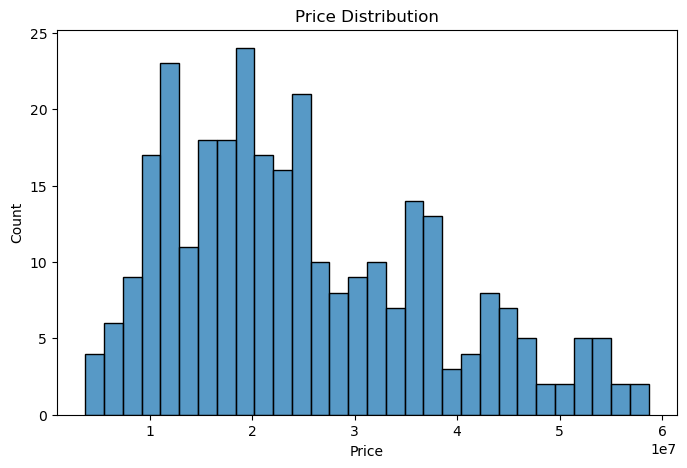

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=30)
plt.title("Price Distribution")
plt.show()

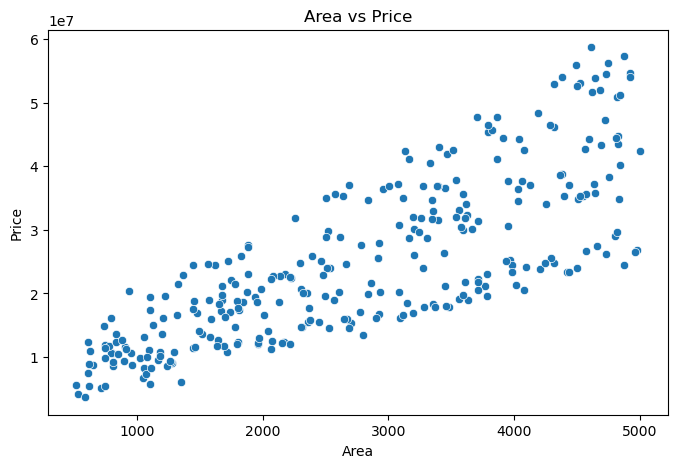

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Area", y="Price", data=df)
plt.title("Area vs Price")
plt.show()

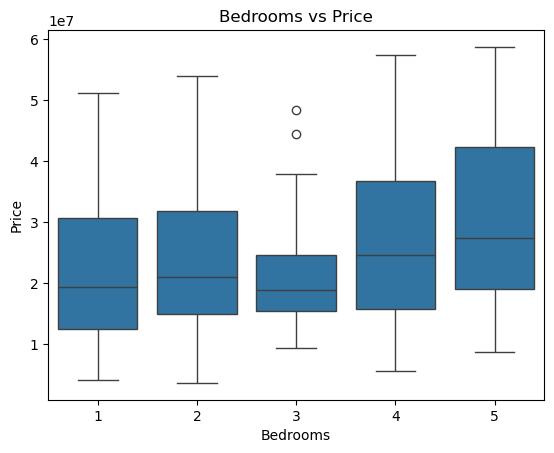

In [15]:
sns.boxplot(x="Bedrooms", y="Price", data=df)
plt.title("Bedrooms vs Price")
plt.show()

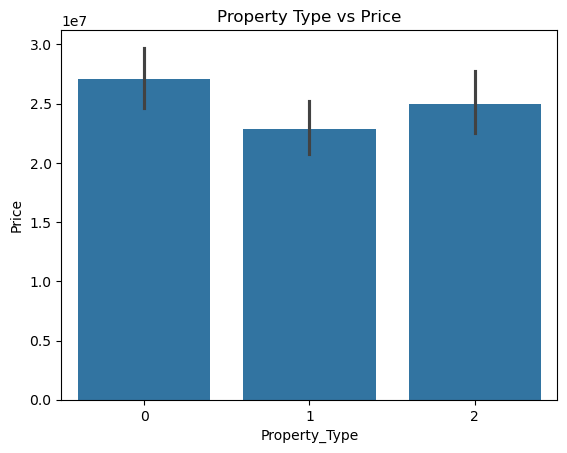

In [16]:
sns.barplot(x="Property_Type", y="Price", data=df)
plt.title("Property Type vs Price")
plt.show()

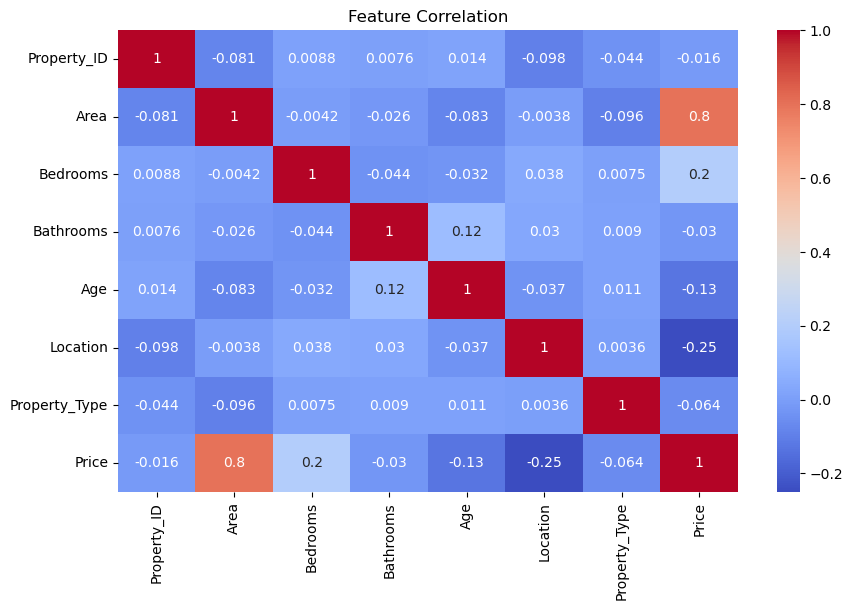

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

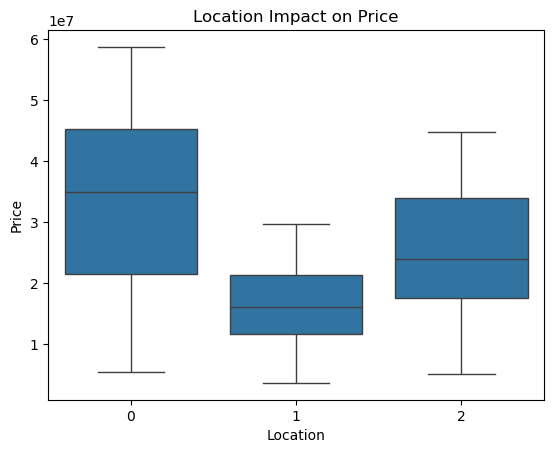

In [18]:
sns.boxplot(x="Location", y="Price", data=df)
plt.title("Location Impact on Price")
plt.show()

In [19]:
df.groupby("Bedrooms")["Price"].mean()

Bedrooms
1    2.251457e+07
2    2.319859e+07
3    2.091230e+07
4    2.704821e+07
5    2.943725e+07
Name: Price, dtype: float64

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\Rittush\Downloads\clean_d.xlsx")

X = df.drop(["Price","Property_ID"], axis=1)
y = df["Price"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score: 0.7045684833622563
RMSE: 6486501.836723112


In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, pred_rf))

Random Forest R2: 0.9729700670841233


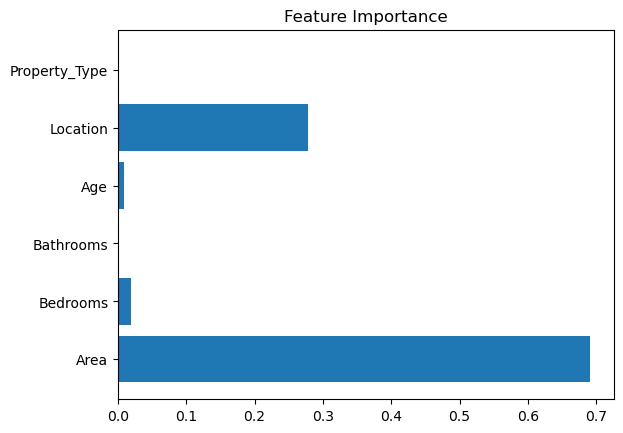

In [24]:
importance = rf.feature_importances_

features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [25]:
from scipy.stats import pearsonr
corr, p_value = pearsonr(df["Area"], df["Price"])
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.7962872550345914
P-value: 5.108233445847768e-67


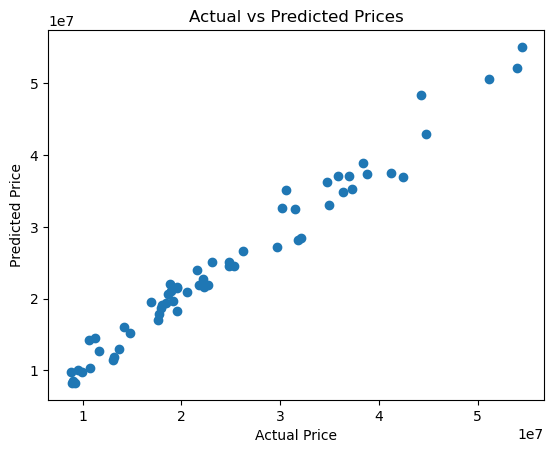

In [26]:
plt.scatter(y_test, pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [28]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
r2 = r2_score(y_test, pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
accuracy = r2 * 100
print("Model Accuracy:", round(accuracy,2), "%")
print("R2 Score:", r2)
print("RMSE:", rmse)

Model Accuracy: 97.3 %
R2 Score: 0.9729700670841233
RMSE: 1962025.3636628273
